### Importing Libraries

In [2]:
import  pandas as pd
import numpy as np

In [3]:
df = pd.read_excel("../Datasets/Real_estate_valuation.xlsx")

In [4]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
df.shape

(414, 8)

In [6]:
df = df.rename(columns={"X1 transaction date" : "transaction_date",
                        "X2 house age":"house_age",
                        "X3 distance to the nearest MRT station": "distance_to_mrt_station",
                        "X4 number of convenience stores": "no_of_convenience_stores",
                        "X5 latitude" : "latitude",
                        "X6 longitude" : "longitude",
                        "Y house price of unit area" : "Y_house_price_unit_area"})
df.head()

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


## First we will Build of Two Vriables then Convert it to all variables
### We will Use Two Approaches
- First is Simple Approach W@X
- Second Is SkLearn Approach

### First Approach Setting Weights and Extracting Inputs and Outputs

In [7]:
# W.shape = (1, d), where d = number of features
# Prediction shape = (1, n), where n = number of samples
## W@X
X = df[["transaction_date","house_age","no_of_convenience_stores","distance_to_mrt_station","latitude","longitude"]].to_numpy().T
Y = df["Y_house_price_unit_area"].to_numpy().T
# No of columns will be equal to the no of rows in Input
W = np.random.randn(1,X.shape[0])
print(f"W vector is {W}")
print(f"shape of X = {X.shape} ")
print(f"shape of Y = {Y.shape} ")



W vector is [[-0.17376626 -1.12094717  0.24108374 -0.89083522 -0.59686893  1.62607788]]
shape of X = (6, 414) 
shape of Y = (414,) 


## Normalizing our Data

In [8]:
# axis=1 is applied on columns horizontally
# First Approach
X_norm = (X - np.mean(X,axis = 1, keepdims= True))/ np.std(X, axis=1, keepdims= True)
Y_norm = (Y - np.mean(Y))/ np.std(Y)

### Loss Function MSE


In [9]:
def loss_func(Y, Y_hat):
    return (1/(2*len(Y)))*np.sum((Y - Y_hat)**2)


## Gradient Descent for Multiple Linear Regression

We are implementing Multiple Linear Regression using two different matrix orientations.

Both approaches are mathematically equivalent.
The main difference is the orientation of the input matrix $X$ and the weight matrix $W$.

---

# Approach 1 — Features × Samples

In the first approach:

- Rows represent **features**
- Columns represent **samples**

Therefore:

$$
X \in \mathbb{R}^{d \times n}
$$

$$
W \in \mathbb{R}^{1 \times d}
$$

where:

- $d$ = number of features
- $n$ = number of training samples

In our current dataset:

$$
X = (6 \times 414)
$$

$$
W = (1 \times 6)
$$

### Prediction

The prediction is calculated as:

$$
\hat{Y} = WX + b
$$

Shape calculation:

$$
(1 \times d)(d \times n)
=
(1 \times n)
$$

For our dataset:

$$
(1 \times 6)(6 \times 414)
=
(1 \times 414)
$$

Therefore, the model produces one prediction for every training sample.

### Error

The prediction error is:

$$
E = \hat{Y} - Y
$$

where:

$$
E \in \mathbb{R}^{1 \times n}
$$

### Gradient with Respect to Weights

For this matrix orientation:

$$
\frac{\partial J}{\partial W}
=
\frac{1}{n}
(\hat{Y}-Y)X^T
$$

Shape calculation:

$$
(1 \times n)(n \times d)
=
(1 \times d)
$$

For our dataset:

$$
(1 \times 414)(414 \times 6)
=
(1 \times 6)
$$

Therefore:

$$
dW \in \mathbb{R}^{1 \times d}
$$

which gives one gradient for every weight.

In NumPy:

```python
dw = ((Y_hat - Y) @ X.T) / n
```

In [10]:
def dEdw(Y,Y_hat,X):
    n = len(Y)
    return  (Y_hat - Y)@X.T/n
def dEdb(Y, Y_hat):
    n = len(Y)
    return  np.sum((Y_hat - Y))/n
b = 0
Y_hat = W@X +b

print(dEdw(Y,Y_hat, X))
print(dEdb(Y, Y_hat))
Y_hat

[[-2394679.32646712   -21508.85710902    -2902.07914206 -2694328.75873382
    -29692.76605974  -144551.29348113]]
-1189.5094282271532


array([[ -276.12718485,  -459.86835432,  -681.50598378,  -681.49150326,
         -519.36584444, -2111.87317104,  -759.41214756,  -444.6518693 ,
        -5112.83793163, -1775.03471564,  -566.83481428,  -252.59091735,
         -618.91256684, -2388.99630836, -1218.68208459,  -722.67529147,
         -426.6684854 ,  -499.18647858,  -512.08948894,  -187.82494473,
        -2198.92882078,  -425.90769403, -1394.9194628 ,  -425.40139306,
         -638.71338379, -1524.92328348,  -511.23165212,  -423.82118929,
         -684.33336482,  -575.80552477, -4222.53901225,  -883.93971951,
         -644.50994388,  -472.47808415,  -365.5460271 , -3816.8811888 ,
        -1906.85490153, -1391.93634702,  -683.89022355,  -441.78692325,
        -3818.75125949, -3808.68284955,  -669.14953386,  -660.94677893,
         -644.45498316,  -641.62377493,  -602.59568448,  -777.48285966,
        -4297.28260825, -4217.76537761,  -647.09580438, -1768.34044306,
        -1483.99823353,  -619.27781202,  -441.66034801, -1236.50

### train function

In [11]:
def train(X, Y, W, b, learning_rate = 0.1, num_iter = 500):
    for i in range(num_iter):

        Y_hat = W@X +b
        dw = dEdw(Y,Y_hat, X)
        db = dEdb(Y, Y_hat)
        W = W - learning_rate * dw
        b = b - learning_rate * db

        Y_hat = W@X +b


        loss = loss_func(Y, Y_hat)
        print(f"Loss in {i} iteration : {loss}")
    return W,b
W,b = train(X_norm, Y_norm,  W, b)

Loss in 0 iteration : 1.8571840685856653
Loss in 1 iteration : 1.4712005035519877
Loss in 2 iteration : 1.205548440281901
Loss in 3 iteration : 1.0142487083046092
Loss in 4 iteration : 0.8708991240026397
Loss in 5 iteration : 0.7599212226541435
Loss in 6 iteration : 0.6718027805611441
Loss in 7 iteration : 0.6004962161293561
Loss in 8 iteration : 0.5419832428069888
Loss in 9 iteration : 0.4934728876096927
Loss in 10 iteration : 0.4529454502565962
Loss in 11 iteration : 0.41888698766665156
Loss in 12 iteration : 0.3901299792787956
Loss in 13 iteration : 0.36575415195390604
Loss in 14 iteration : 0.3450221567861399
Loss in 15 iteration : 0.32733602464430417
Loss in 16 iteration : 0.31220645163638866
Loss in 17 iteration : 0.29923032908448643
Loss in 18 iteration : 0.28807379933304944
Loss in 19 iteration : 0.2784591702245456
Loss in 20 iteration : 0.27015462541453794
Loss in 21 iteration : 0.2629660242742306
Loss in 22 iteration : 0.25673030248056905
Loss in 23 iteration : 0.251310121993

### Predict Function


In [12]:
def predict(W,b,X):
    return W@X +b

### Comparison With SkLearn


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# X_norm = (features, samples)
# sklearn requires in this shape  (samples, features)
model.fit(X_norm.T, Y_norm)

print("Scratch W:", W)
print("Scratch b:", b)

print("Sklearn W:", model.coef_)
print("Sklearn b:", model.intercept_)

Scratch W: [[ 0.10670529 -0.22581522  0.24537968 -0.41607938  0.20568848 -0.01389478]]
Scratch b: 3.682829671928745e-15
Sklearn W: [ 0.10671371 -0.22581256  0.24534464 -0.41625196  0.20564666 -0.01401913]
Sklearn b: 3.4405522650543835e-15


### For Second Approach which used in Sklearn


### Second Approach Setting Weights and Extracting Inputs and Outputs

In [14]:
# Will Matrix Mul be X@W  In Matrix mul we have to match the Inner Dimensions Like (3x2) (2x1)  final shape wil be outer dimension multiplier
# W.shape = (d, 1), where d = number of features
# Prediction shape = (n, 1)
X = df[["house_age","no_of_convenience_stores"]].to_numpy()
Y = df["Y_house_price_unit_area"].to_numpy()
# No of rows will be equal to the no of columns in Input
W = np.random.randn(X.shape[1],1)
print(f"W1 is {W}")
print(f"shape of X1 = {X.shape} ")
print(f"shape of Y1 = {Y.shape} ")

W1 is [[-0.10360888]
 [ 0.4687698 ]]
shape of X1 = (414, 2) 
shape of Y1 = (414,) 


### Normalizing Our Data

In [15]:

# Second Approach
X_norm  = (X - np.mean(X,axis = 0 ,keepdims= True)) / np.std(X, axis = 0, keepdims=True)
Y_norm = (Y - np.mean(Y))/ np.std(Y)

# Approach 2 — Samples × Features

In the second approach:

- Rows represent **samples**
- Columns represent **features**

Therefore:

$$
X \in \mathbb{R}^{n \times d}
$$

$$
W \in \mathbb{R}^{d \times 1}
$$

where:

- $n$ = number of training samples
- $d$ = number of features

In our current dataset:

$$
X = (414 \times 2)
$$

$$
W = (2 \times 1)
$$

### Prediction

The prediction is calculated as:

$$
\hat{Y} = XW + b
$$

Shape calculation:

$$
(n \times d)(d \times 1)
=
(n \times 1)
$$

For our dataset:

$$
(414 \times 2)(2 \times 1)
=
(414 \times 1)
$$

Therefore, the model produces one prediction for every training sample.

### Error

The prediction error is:

$$
E = \hat{Y} - Y
$$

where:

$$
E \in \mathbb{R}^{n \times 1}
$$

For our dataset:

$$
E = (414 \times 1)
$$

### Gradient with Respect to Weights

In our implementation, we first calculate:

$$
dW^T
=
\frac{1}{n}
(\hat{Y}-Y)^T X
$$

Shape calculation:

$$
(1 \times n)(n \times d)
=
(1 \times d)
$$

For our dataset:

$$
(1 \times 414)(414 \times 2)
=
(1 \times 2)
$$

Therefore:

$$
dW^T \in \mathbb{R}^{1 \times d}
$$

which gives one gradient value for every weight.

In NumPy:

```python
diff = Y_hat - Y
dw = (diff.T @ X) / n
```

In [16]:
def dEdw(Y,Y_hat,X):
    diff = Y_hat - Y
    return (X.T @  diff) / len(Y)

def dEdb(Y,Y_hat):
    return np.sum((Y_hat-Y)) / len(Y)
b = 0




### Training Function

In [17]:

def train(X_norm, Y_norm, W, b, learning_rate = 0.1, num_iter = 150):
    for i in range(num_iter):
        Y_hat  = X_norm @ W + b
        dw = dEdw(Y_norm,Y_hat,X_norm)
        db = dEdb(Y_norm,Y_hat)
        W = W-  learning_rate * dw
        b = b - learning_rate * db
        Y_hat  = X_norm @ W + b

        loss = loss_func(Y_norm,Y_hat)
        print(f" Loss After iter {i} is : {loss}")
    return W, b


In [18]:
Y_norm = Y_norm.reshape(-1,1)
W, b = train(X_norm, Y_norm, W, b)

 Loss After iter 0 is : 0.3206320691105309
 Loss After iter 1 is : 0.3184108798301955
 Loss After iter 2 is : 0.31659218733400907
 Loss After iter 3 is : 0.31510304982201226
 Loss After iter 4 is : 0.3138837454908466
 Loss After iter 5 is : 0.3128853762902639
 Loss After iter 6 is : 0.3120679060693977
 Loss After iter 7 is : 0.31139855435710645
 Loss After iter 8 is : 0.3108504813011881
 Loss After iter 9 is : 0.3104017109819457
 Loss After iter 10 is : 0.3100342498861884
 Loss After iter 11 is : 0.30973336516282535
 Loss After iter 12 is : 0.3094869936955127
 Loss After iter 13 is : 0.30928525827902364
 Loss After iter 14 is : 0.3091200714850623
 Loss After iter 15 is : 0.30898481132280475
 Loss After iter 16 is : 0.3088740556808766
 Loss After iter 17 is : 0.3087833648964938
 Loss After iter 18 is : 0.3087091037288117
 Loss After iter 19 is : 0.3086482955947179
 Loss After iter 20 is : 0.3085985032198404
 Loss After iter 21 is : 0.3085577309173982
 Loss After iter 22 is : 0.308524344

### Predict Function

In [19]:
def predict(W,b,X):
    return X @ W + b

Y_hat = predict(W, b, X_norm)


### Comparison with Sklearn

In [20]:
model = LinearRegression()
model.fit(X_norm,Y_norm)

print(f"W from scratch {W}")
print(f"b1 from scratch {b}")
print(f"SkLearn W1 {model.coef_}")
print(f"SkLearn b1 {model.intercept_}")


W from scratch [[-0.23947354]
 [ 0.58288097]]
b1 from scratch 7.380033245817461e-17
SkLearn W1 [[-0.23947358  0.58288101]]
SkLearn b1 [6.80995133e-17]


### Denormalization

After prediction, the output is still in the normalized scale.

To bring predictions back to their original units, we reverse the normalization:

$$
Y_{\text{original}} = Y_{\text{normalized}} \times \sigma_Y + \mu_Y
$$

In NumPy:

```python
Y_hat_original = Y_hat * np.std(Y) + np.mean(Y)
```

In [21]:

Y_hat_orignal = Y_hat * np.std(Y) + np.mean(Y)
df = pd.DataFrame({
    "Y_orignal" : Y.ravel(),
    "Y_predicted" : Y_hat_orignal.ravel()
})

In [22]:
df.head()

,Y_orignal,Y_predicted
0,37.9,49.795240
1,42.2,50.677884
2,47.3,41.681111
3,54.8,41.681111
4,43.1,44.055016


In [23]:
Y.shape

(414,)

### Plotting Data

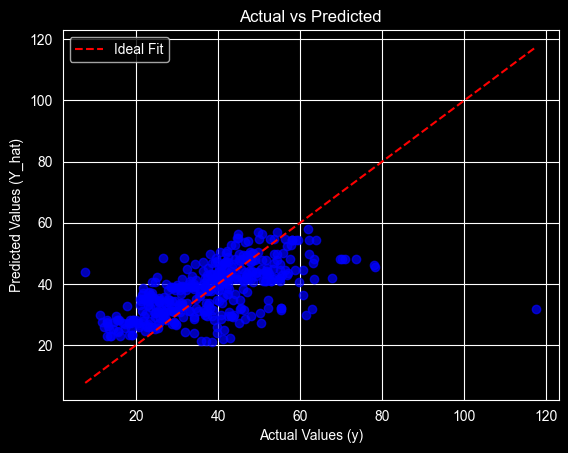

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Both y and Y_hat_original must have shape (m,)
plt.scatter(Y, Y_hat_orignal, c="b", alpha=0.7)

# Draw a reference ideal line (y = x)
min_val = min(np.min(Y), np.min(Y_hat_orignal))
max_val = max(np.max(Y), np.max(Y_hat_orignal))
plt.plot([min_val, max_val], [min_val, max_val], c="r", linestyle="--", label="Ideal Fit")

plt.xlabel("Actual Values (y)")
plt.ylabel("Predicted Values (Y_hat)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

### Testing Our Class

In [25]:
from LinearRegression import LinearRegression

In [28]:
model = LinearRegression(learning_rate=0.1,epochs=50)
model.fit(X_norm,Y_norm)


Epoch 0: Loss 1.4460499319568756
Epoch 49: Loss 0.3084370187175209
